### 1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay ,mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from pandas.plotting import scatter_matrix
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
from joblib import dump



#2. Load Dataset

In [26]:
all_data = []
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS',
    'GAIL.NS', 'TATASTEEL.NS', 'SBIN.NS', 'AXISBANK.NS', 'WIPRO.NS',
    'HCLTECH.NS', 'ONGC.NS', 'NTPC.NS', 'MARUTI.NS', 'SUNPHARMA.NS',
    'DRREDDY.NS', 'CIPLA.NS', 'ITC.NS', 'LT.NS'
]
for ticker in tickers:
    try:
        df = yf.download(
            ticker,
            start="2019-01-01",
            interval="1d",
            progress=False
        )

        if df.empty:
            print(f"❌ {ticker}: Empty data")
            continue

        df.columns = df.columns.droplevel(1)
        df.reset_index(inplace=True)
        df.columns.name = None
        df = df[df['Volume'] > 0]

        if len(df) < 100:
            print(f"❌ {ticker}: Too few rows ({len(df)})")
            continue

        df['Ticker'] = ticker

        if 'Adj Close' in df.columns:
            df.drop(columns=['Adj Close'], inplace=True)

        all_data.append(df)
        print(f"✅ {ticker}: {len(df)} rows")

    except Exception as e:
        print(f"❌ {ticker}: {e}")

combined_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal stocks : {len(all_data)}")
print(f"Total rows   : {len(combined_df)}")
print(f"Columns      : {combined_df.columns.tolist()}")

✅ RELIANCE.NS: 1856 rows
✅ TCS.NS: 1856 rows
✅ INFY.NS: 1856 rows
✅ HDFCBANK.NS: 1856 rows
✅ ICICIBANK.NS: 1856 rows
✅ GAIL.NS: 1856 rows
✅ TATASTEEL.NS: 1856 rows
✅ SBIN.NS: 1856 rows
✅ AXISBANK.NS: 1856 rows
✅ WIPRO.NS: 1856 rows
✅ HCLTECH.NS: 1856 rows
✅ ONGC.NS: 1856 rows
✅ NTPC.NS: 1856 rows
✅ MARUTI.NS: 1856 rows
✅ SUNPHARMA.NS: 1856 rows
✅ DRREDDY.NS: 1856 rows
✅ CIPLA.NS: 1856 rows
✅ ITC.NS: 1857 rows
✅ LT.NS: 1856 rows

Total stocks : 19
Total rows   : 35265
Columns      : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


#Know Your Data


In [27]:
df.head(5)

,Date,Close,High,Low,Open,Volume,Ticker
0,2019-01-01,1283.006348,1285.764714,1268.146580,1285.764714,786846,LT.NS
1,2019-01-02,1268.413574,1285.675766,1260.939211,1282.205514,2058504,LT.NS
2,2019-01-03,1241.274536,1271.527822,1237.715326,1268.858415,2290756,LT.NS
3,2019-01-04,1235.090576,1252.486152,1222.188438,1247.414321,2711485,LT.NS
4,2019-01-07,1231.308838,1253.375876,1227.082276,1243.054188,1851513,LT.NS


In [28]:
print("Shape of Stock Data :",df.shape)
print("DataType of Stock Data :",df.dtypes)
print("Info of Stock Data :",df.info())
print(df.describe())
print("Missing Value in Stock Data:",df.isnull().sum())


Shape of Stock Data : (1856, 7)
DataType of Stock Data : Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Ticker            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 1856 entries, 0 to 1860
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1856 non-null   datetime64[ns]
 1   Close   1856 non-null   float64       
 2   High    1856 non-null   float64       
 3   Low     1856 non-null   float64       
 4   Open    1856 non-null   float64       
 5   Volume  1856 non-null   int64         
 6   Ticker  1856 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 116.0+ KB
Info of Stock Data : None
                                Date        Close         High          Low  \
count                           1856  1856.000000  1856.000000  1856.

In [29]:
# Saare stocks ka tail dekho
print("Unique tickers:", combined_df['Ticker'].unique())
print("Rows per ticker:")
print(combined_df['Ticker'].value_counts())

Unique tickers: ['RELIANCE.NS' 'TCS.NS' 'INFY.NS' 'HDFCBANK.NS' 'ICICIBANK.NS' 'GAIL.NS'
 'TATASTEEL.NS' 'SBIN.NS' 'AXISBANK.NS' 'WIPRO.NS' 'HCLTECH.NS' 'ONGC.NS'
 'NTPC.NS' 'MARUTI.NS' 'SUNPHARMA.NS' 'DRREDDY.NS' 'CIPLA.NS' 'ITC.NS'
 'LT.NS']
Rows per ticker:
Ticker
ITC.NS          1857
TCS.NS          1856
RELIANCE.NS     1856
INFY.NS         1856
HDFCBANK.NS     1856
GAIL.NS         1856
ICICIBANK.NS    1856
SBIN.NS         1856
AXISBANK.NS     1856
WIPRO.NS        1856
TATASTEEL.NS    1856
HCLTECH.NS      1856
ONGC.NS         1856
MARUTI.NS       1856
NTPC.NS         1856
SUNPHARMA.NS    1856
DRREDDY.NS      1856
CIPLA.NS        1856
LT.NS           1856
Name: count, dtype: int64


Enter Stock in Capital Letters and add .NS at the end :GAIL.NS


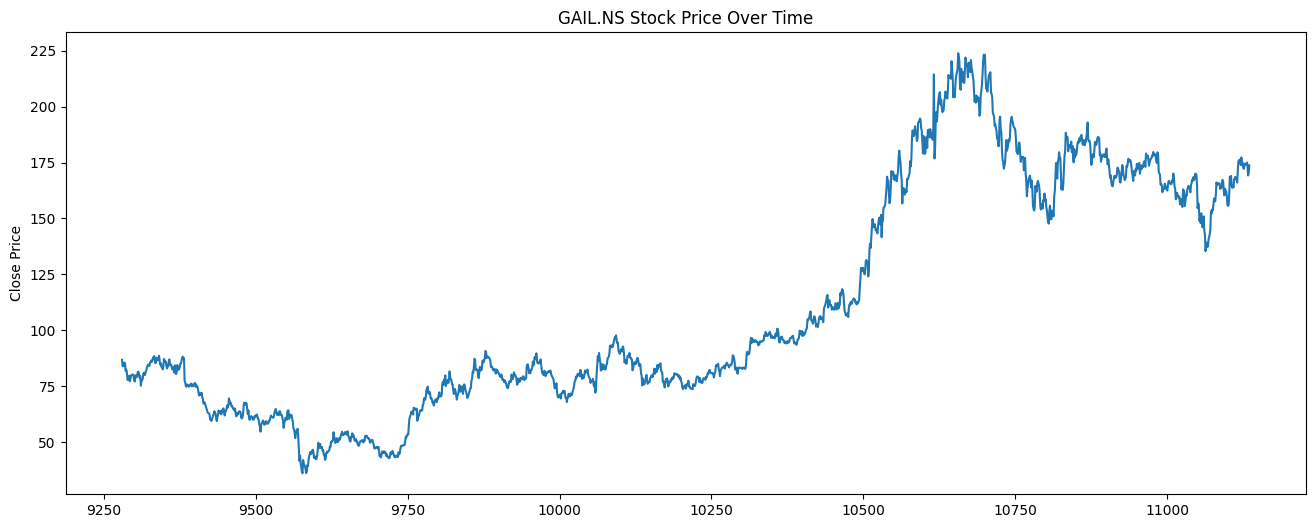

In [30]:
ticker=input("Enter Stock in Capital Letters and add .NS at the end :")
if ticker in combined_df['Ticker'].unique():
    stock_df = combined_df[
                combined_df['Ticker'] == ticker]
    stock_df['Close'].plot(
        figsize=(16, 6),
        title=f"{ticker} Stock Price Over Time"
    )
    plt.ylabel("Close Price")
    plt.show()
else:
    print(f"❌ {ticker} not found!")
    print(f"Available stocks: {combined_df['Ticker'].unique()}")

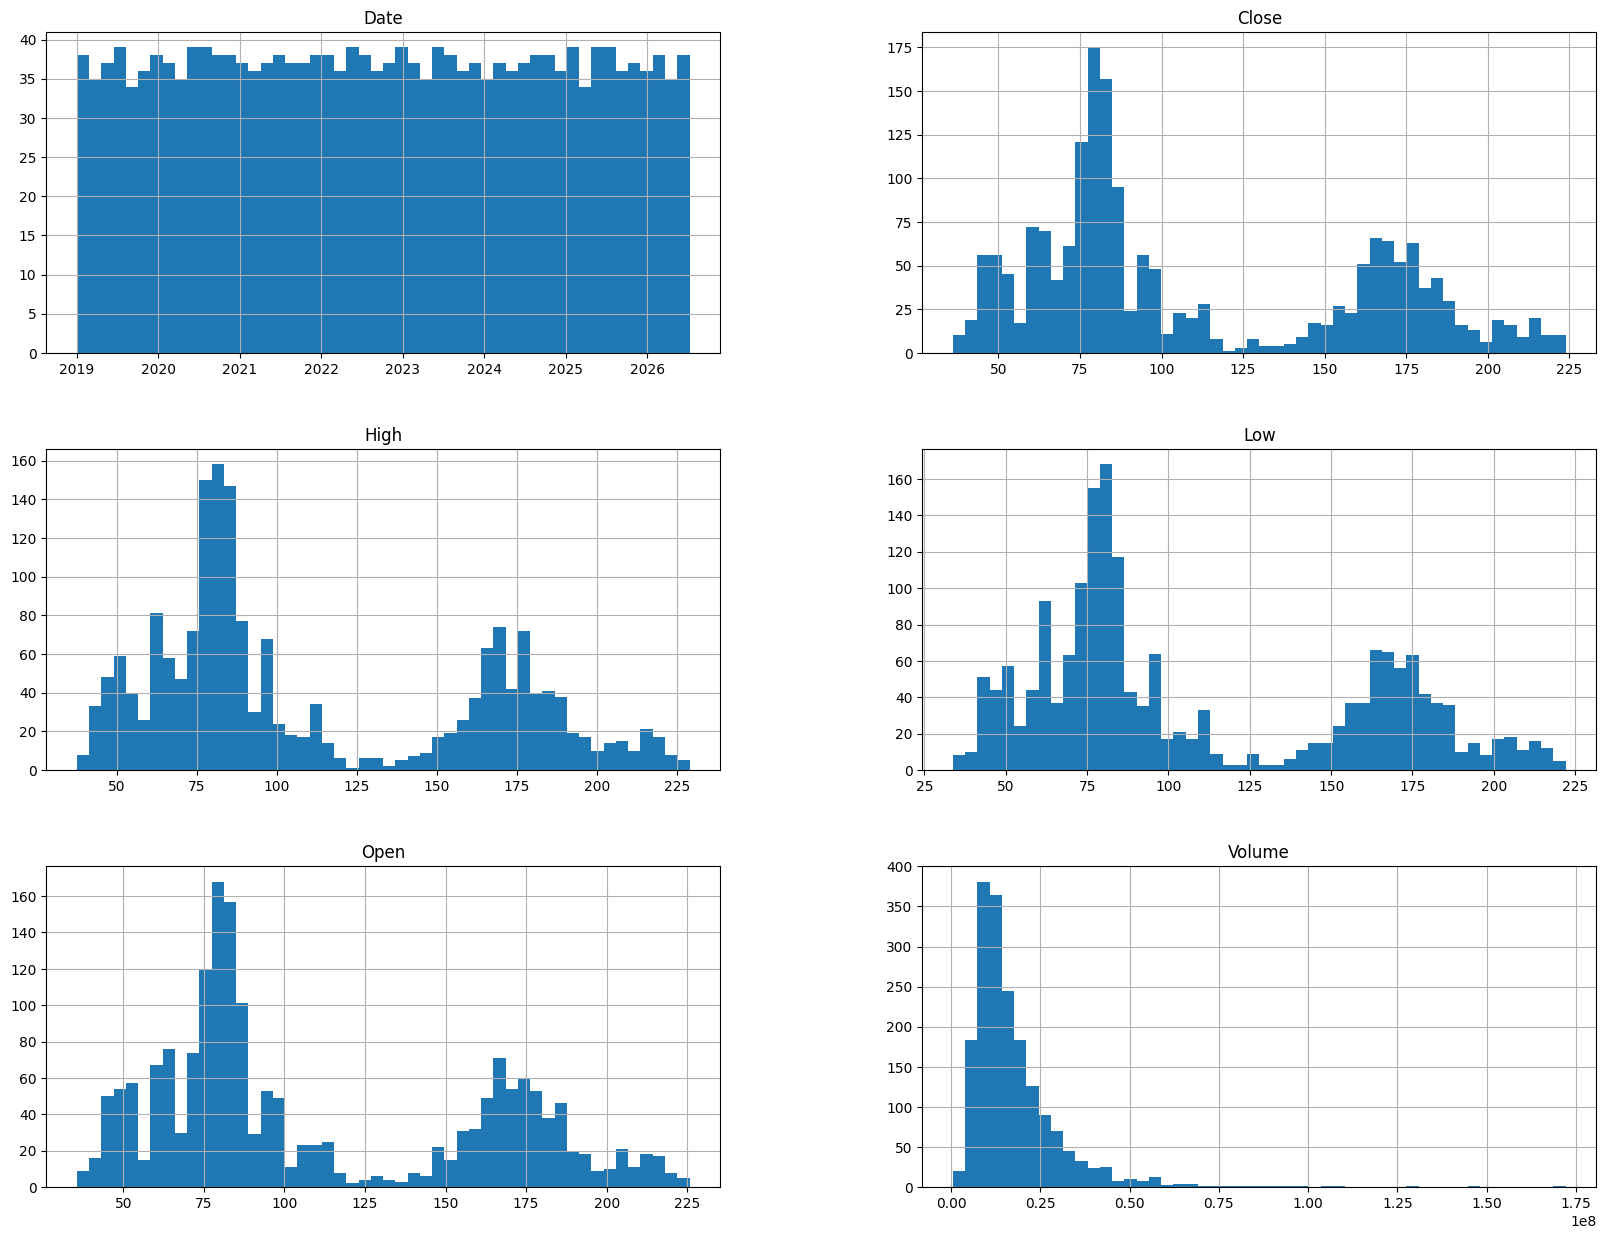

In [31]:
df_hist=combined_df[combined_df['Ticker']==ticker]
df_hist.hist(bins=50 ,figsize=(20,15))
plt.show()

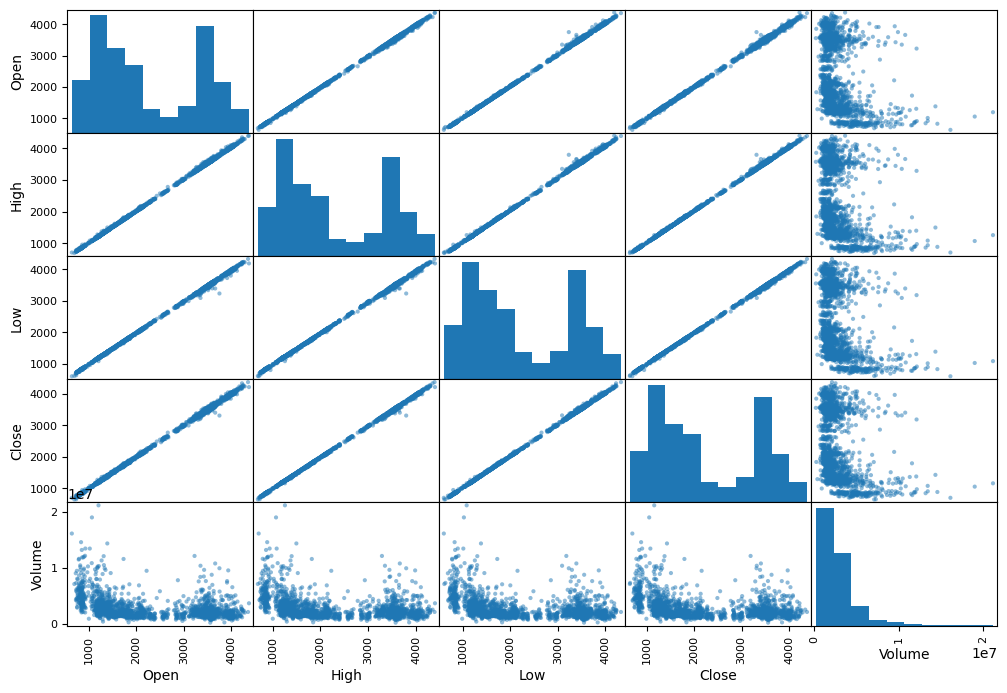

In [32]:
stock_df.drop(columns=['Ticker'], inplace=True)
stock_df.corr()
attributes = ["Open", "High", "Low", "Close", "Volume"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

# Data preprocessing

##Handling Missing Values


In [33]:
def check_zero_values(combined_df):
    print("=" * 50)
    print("ZERO VALUES CHECK - ALL STOCKS")
    print("=" * 50)

    for ticker in combined_df['Ticker'].unique():
        stock_df = combined_df[
                    combined_df['Ticker'] == ticker]

        # Zero volume check
        zero_vol = (stock_df['Volume'] == 0).sum()

        # Zero price check
        zero_close = (stock_df['Close'] == 0).sum()
        zero_open  = (stock_df['Open'] == 0).sum()
        zero_high  = (stock_df['High'] == 0).sum()
        zero_low   = (stock_df['Low'] == 0).sum()

        if zero_vol > 0 or zero_close > 0:
            print(f"\n⚠️  {ticker}:")
            print(f"   Volume == 0 : {zero_vol}")
            print(f"   Close  == 0 : {zero_close}")
            print(f"   Open   == 0 : {zero_open}")
            print(f"   High   == 0 : {zero_high}")
            print(f"   Low    == 0 : {zero_low}")
        else:
            print(f"✅ {ticker}: No zero values")

    print("\n" + "=" * 50)

# Call karo
check_zero_values(combined_df)

ZERO VALUES CHECK - ALL STOCKS
✅ RELIANCE.NS: No zero values
✅ TCS.NS: No zero values
✅ INFY.NS: No zero values
✅ HDFCBANK.NS: No zero values
✅ ICICIBANK.NS: No zero values
✅ GAIL.NS: No zero values
✅ TATASTEEL.NS: No zero values
✅ SBIN.NS: No zero values
✅ AXISBANK.NS: No zero values
✅ WIPRO.NS: No zero values
✅ HCLTECH.NS: No zero values
✅ ONGC.NS: No zero values
✅ NTPC.NS: No zero values
✅ MARUTI.NS: No zero values
✅ SUNPHARMA.NS: No zero values
✅ DRREDDY.NS: No zero values
✅ CIPLA.NS: No zero values
✅ ITC.NS: No zero values
✅ LT.NS: No zero values



In [34]:
def remove_zero_values(combined_df):
    print("=" * 50)
    print("Fake vs Real Zero Volume  CHECK - ALL STOCKS")
    print("=" * 50)

    for ticker in combined_df['Ticker'].unique():
        stock_df = combined_df[
                    combined_df['Ticker'] == ticker]
        #Case A
        Fake_Rows = (stock_df['Open'] == stock_df['Close']) & \
            (stock_df['Close'] == stock_df['High']) & \
            (stock_df['High'] == stock_df['Low']) & \
             (stock_df['Volume']==0)

        stock_df = stock_df[~Fake_Rows]
        print("After Removal of Fake rows number of Zero Volume :",len(stock_df[stock_df['Volume']==0]))
         #Case B

        real_zero_vol=stock_df[stock_df['Volume']==0]
        print("Number of Real Zero Volume :",len(real_zero_vol))
        stock_df['Volume']=stock_df['Volume'].replace(0,None)
        stock_df['Volume']=stock_df['Volume'].interpolate(method='linear')


In [35]:
remove_zero_values(combined_df)

Fake vs Real Zero Volume  CHECK - ALL STOCKS
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows number of Zero Volume : 0
Number of Real Zero Volume : 0
After Removal of Fake rows numb

In [36]:
zero_vol = df[df['Volume'] == 0]
print(f"Total: {len(zero_vol)}")

Total: 0


## Outlier Detection and Manage :


In [37]:
def check_outliers(combined_df):
    print("=" * 50)
    print("OUTLIER CHECK - ALL STOCKS")
    print("=" * 50)

    for ticker in combined_df['Ticker'].unique():
        stock_df = combined_df[
                    combined_df['Ticker'] == ticker]

        Q1  = stock_df['Volume'].quantile(0.25)
        Q3  = stock_df['Volume'].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + 1.5 * IQR

        outliers = stock_df[stock_df['Volume'] > upper]

        if len(outliers) > 0:
            print(f"\n {ticker}:")
            print(f"   Volume outliers : {len(outliers)}")
            print(f"   Max Volume      : {stock_df['Volume'].max():,.0f}")
            print(f"   Upper bound     : {upper:,.0f}")
        else:
            print(f"✅ {ticker}: No volume outliers")

    print("\n" + "=" * 50)

check_outliers(combined_df)

OUTLIER CHECK - ALL STOCKS

 RELIANCE.NS:
   Volume outliers : 132
   Max Volume      : 142,683,366
   Upper bound     : 37,726,652

 TCS.NS:
   Volume outliers : 109
   Max Volume      : 19,839,329
   Upper bound     : 5,766,785

 INFY.NS:
   Volume outliers : 123
   Max Volume      : 90,432,109
   Upper bound     : 15,786,472

 HDFCBANK.NS:
   Volume outliers : 62
   Max Volume      : 445,342,100
   Upper bound     : 60,906,617

 ICICIBANK.NS:
   Volume outliers : 119
   Max Volume      : 286,857,658
   Upper bound     : 38,060,234

 GAIL.NS:
   Volume outliers : 110
   Max Volume      : 172,072,992
   Upper bound     : 39,034,953

 TATASTEEL.NS:
   Volume outliers : 91
   Max Volume      : 642,845,990
   Upper bound     : 236,700,150

 SBIN.NS:
   Volume outliers : 160
   Max Volume      : 214,955,688
   Upper bound     : 58,675,992

 AXISBANK.NS:
   Volume outliers : 174
   Max Volume      : 96,186,227
   Upper bound     : 24,188,461

 WIPRO.NS:
   Volume outliers : 142
   Max Volu

In [38]:
def handle_volume_outliers(combined_df):
    print("Volume Log Transform - All Stocks")
    print("=" * 50)

    processed = []

    for ticker in combined_df['Ticker'].unique():
        stock_df = combined_df[
                    combined_df['Ticker'] == ticker].copy()

        # Log transform
        stock_df['Volume_log'] = np.log1p(stock_df['Volume'])

        # Before vs After
        vol_max     = stock_df['Volume'].max()
        vol_log_max = stock_df['Volume_log'].max()

        if vol_max > 0:
            print(f"✅ {ticker}:")
            print(f"   Max Volume     : {vol_max:,.0f}")
            print(f"   Max Volume_log : {vol_log_max:.2f}")

        processed.append(stock_df)

    return pd.concat(processed, ignore_index=True)

combined_df = handle_volume_outliers(combined_df)
print(f"\nShape: {combined_df.shape}")

Volume Log Transform - All Stocks
✅ RELIANCE.NS:
   Max Volume     : 142,683,366
   Max Volume_log : 18.78
✅ TCS.NS:
   Max Volume     : 19,839,329
   Max Volume_log : 16.80
✅ INFY.NS:
   Max Volume     : 90,432,109
   Max Volume_log : 18.32
✅ HDFCBANK.NS:
   Max Volume     : 445,342,100
   Max Volume_log : 19.91
✅ ICICIBANK.NS:
   Max Volume     : 286,857,658
   Max Volume_log : 19.47
✅ GAIL.NS:
   Max Volume     : 172,072,992
   Max Volume_log : 18.96
✅ TATASTEEL.NS:
   Max Volume     : 642,845,990
   Max Volume_log : 20.28
✅ SBIN.NS:
   Max Volume     : 214,955,688
   Max Volume_log : 19.19
✅ AXISBANK.NS:
   Max Volume     : 96,186,227
   Max Volume_log : 18.38
✅ WIPRO.NS:
   Max Volume     : 260,735,176
   Max Volume_log : 19.38
✅ HCLTECH.NS:
   Max Volume     : 33,066,256
   Max Volume_log : 17.31
✅ ONGC.NS:
   Max Volume     : 178,094,829
   Max Volume_log : 19.00
✅ NTPC.NS:
   Max Volume     : 216,981,706
   Max Volume_log : 19.20
✅ MARUTI.NS:
   Max Volume     : 4,892,962
   Ma

In [39]:
# Outliers check karo after log transform
def check_outliers_after_log(combined_df):
    print("\nOUTLIER CHECK AFTER LOG TRANSFORM")
    print("=" * 50)

    for ticker in combined_df['Ticker'].unique():
        stock_df = combined_df[
                    combined_df['Ticker'] == ticker]

        Q1    = stock_df['Volume_log'].quantile(0.25)
        Q3    = stock_df['Volume_log'].quantile(0.75)
        IQR   = Q3 - Q1
        upper = Q3 + 1.5 * IQR

        outliers = stock_df[
                    stock_df['Volume_log'] > upper]

        print(f"{'✅' if len(outliers)==0 else '⚠️'} "
              f"{ticker}: {len(outliers)} outliers remaining")

check_outliers_after_log(combined_df)


OUTLIER CHECK AFTER LOG TRANSFORM
⚠️ RELIANCE.NS: 32 outliers remaining
⚠️ TCS.NS: 23 outliers remaining
⚠️ INFY.NS: 37 outliers remaining
⚠️ HDFCBANK.NS: 8 outliers remaining
⚠️ ICICIBANK.NS: 32 outliers remaining
⚠️ GAIL.NS: 20 outliers remaining
✅ TATASTEEL.NS: 0 outliers remaining
⚠️ SBIN.NS: 15 outliers remaining
⚠️ AXISBANK.NS: 53 outliers remaining
⚠️ WIPRO.NS: 53 outliers remaining
⚠️ HCLTECH.NS: 26 outliers remaining
⚠️ ONGC.NS: 21 outliers remaining
⚠️ NTPC.NS: 24 outliers remaining
⚠️ MARUTI.NS: 6 outliers remaining
⚠️ SUNPHARMA.NS: 17 outliers remaining
⚠️ DRREDDY.NS: 31 outliers remaining
⚠️ CIPLA.NS: 50 outliers remaining
⚠️ ITC.NS: 22 outliers remaining
⚠️ LT.NS: 32 outliers remaining


# Feature Engineering

In [40]:
!pip install ta
import ta
def add_features(df):
    df = df.copy()

    # Per stock normalize karo
    first_price = df['Close'].iloc[0]
    df['Close_norm'] = df['Close'] / first_price * 100
    df['High_norm']  = df['High']  / first_price * 100
    df['Low_norm']   = df['Low']   / first_price * 100
    df['Open_norm']  = df['Open']  / first_price * 100

    # Moving Averages on normalized price
    df['SMA_7']  = df['Close_norm'].rolling(7).mean()
    df['EMA_12'] = df['Close_norm'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close_norm'].ewm(span=26, adjust=False).mean()

    # Momentum
    df['RSI']  = ta.momentum.RSIIndicator(df['Close'], 14).rsi()
    df['MACD'] = df['EMA_12'] - df['EMA_26']

    # Lag Features on normalized price
    df['Lag_1'] = df['Close_norm'].shift(1)
    df['Lag_2'] = df['Close_norm'].shift(2)
    df['Lag_3'] = df['Close_norm'].shift(3)
    df['Lag_7'] = df['Close_norm'].shift(7)

    # Price Features
    df['Daily_Return']    = df['Close'].pct_change()
    df['Close_to_Open']   = df['Close_norm'] - df['Open_norm']
    df['std_5']           = df['Close_norm'].rolling(5).std()
    df['Price_ROC']       = df['Close_norm'].pct_change(5)
    df['Volume_log']      = np.log1p(df['Volume'])
    df['Relative_Volume'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # Normalized Price Targets
    for day in range(1, 8):
        df[f'target_day_{day}'] = df['Close_norm'].shift(-day)

    # Feature NaN handle
    feature_cols = [
        'Close_norm', 'High_norm', 'Low_norm', 'Open_norm',
        'Volume_log', 'SMA_7', 'EMA_12', 'EMA_26',
        'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7',
        'Daily_Return', 'Close_to_Open', 'std_5',
        'Price_ROC', 'Relative_Volume'
    ]
    df[feature_cols] = df[feature_cols].ffill().bfill()

    # Target NaN drop
    target_cols = [f'target_day_{i}' for i in range(1, 8)]
    df.dropna(subset=target_cols, inplace=True)

    return df

# Apply per stock
processed = []

for ticker in combined_df['Ticker'].unique():
    stock_df = combined_df[
                combined_df['Ticker'] == ticker].copy()
    stock_df = add_features(stock_df)
    processed.append(stock_df)
    print(f"✅ {ticker}: {len(stock_df)} rows")

final_df = pd.concat(processed, ignore_index=True)
print(f"\nShape     : {final_df.shape}")
print(f"NaN check : {final_df.isnull().sum().sum()}")

✅ RELIANCE.NS: 1849 rows
✅ TCS.NS: 1849 rows
✅ INFY.NS: 1849 rows
✅ HDFCBANK.NS: 1849 rows
✅ ICICIBANK.NS: 1849 rows
✅ GAIL.NS: 1849 rows
✅ TATASTEEL.NS: 1849 rows
✅ SBIN.NS: 1849 rows
✅ AXISBANK.NS: 1849 rows
✅ WIPRO.NS: 1849 rows
✅ HCLTECH.NS: 1849 rows
✅ ONGC.NS: 1849 rows
✅ NTPC.NS: 1849 rows
✅ MARUTI.NS: 1849 rows
✅ SUNPHARMA.NS: 1849 rows
✅ DRREDDY.NS: 1849 rows
✅ CIPLA.NS: 1849 rows
✅ ITC.NS: 1850 rows
✅ LT.NS: 1849 rows

Shape     : (35132, 33)
NaN check : 0


In [41]:
processed = []

for ticker in combined_df['Ticker'].unique():
    stock_df = combined_df[
                combined_df['Ticker'] == ticker].copy()
    stock_df = add_features(stock_df)
    processed.append(stock_df)
    print(f"✅ {ticker}: {len(stock_df)} rows")

final_df = pd.concat(processed, ignore_index=True)
print(f"\nShape     : {final_df.shape}")
print(f"NaN check : {final_df.isnull().sum().sum()}")
print(f"Columns   : {final_df.columns.tolist()}")

✅ RELIANCE.NS: 1849 rows
✅ TCS.NS: 1849 rows
✅ INFY.NS: 1849 rows
✅ HDFCBANK.NS: 1849 rows
✅ ICICIBANK.NS: 1849 rows
✅ GAIL.NS: 1849 rows
✅ TATASTEEL.NS: 1849 rows
✅ SBIN.NS: 1849 rows
✅ AXISBANK.NS: 1849 rows
✅ WIPRO.NS: 1849 rows
✅ HCLTECH.NS: 1849 rows
✅ ONGC.NS: 1849 rows
✅ NTPC.NS: 1849 rows
✅ MARUTI.NS: 1849 rows
✅ SUNPHARMA.NS: 1849 rows
✅ DRREDDY.NS: 1849 rows
✅ CIPLA.NS: 1849 rows
✅ ITC.NS: 1850 rows
✅ LT.NS: 1849 rows

Shape     : (35132, 33)
NaN check : 0
Columns   : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Volume_log', 'Close_norm', 'High_norm', 'Low_norm', 'Open_norm', 'SMA_7', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Daily_Return', 'Close_to_Open', 'std_5', 'Price_ROC', 'Relative_Volume', 'target_day_1', 'target_day_2', 'target_day_3', 'target_day_4', 'target_day_5', 'target_day_6', 'target_day_7']


# Train/Test Split:

In [44]:
feature_cols = [
    'Close_norm', 'High_norm', 'Low_norm', 'Open_norm',
    'Volume_log', 'SMA_7', 'EMA_12', 'EMA_26',
    'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7',
    'Daily_Return', 'Close_to_Open', 'std_5',
    'Price_ROC', 'Relative_Volume'
]

target_cols = [f'target_day_{i}' for i in range(1, 8)]

# Time based split
train_df = final_df[final_df['Date'] < '2024-01-01']
test_df  = final_df[final_df['Date'] >= '2024-01-01']

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df[target_cols]
y_test  = test_df[target_cols]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (23465, 19)
X_test  : (11667, 19)
y_train : (23465, 7)
y_test  : (11667, 7)


In [45]:
# final_df mein kaunse columns hain
print(final_df.columns.tolist())

# feature_cols mein se kaunsa nahi hai
for col in feature_cols:
    if col not in final_df.columns:
        print(f"❌ Missing: {col}")
    else:
        print(f"✅ Found: {col}")

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Volume_log', 'Close_norm', 'High_norm', 'Low_norm', 'Open_norm', 'SMA_7', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Daily_Return', 'Close_to_Open', 'std_5', 'Price_ROC', 'Relative_Volume', 'target_day_1', 'target_day_2', 'target_day_3', 'target_day_4', 'target_day_5', 'target_day_6', 'target_day_7']
✅ Found: Close_norm
✅ Found: High_norm
✅ Found: Low_norm
✅ Found: Open_norm
✅ Found: Volume_log
✅ Found: SMA_7
✅ Found: EMA_12
✅ Found: EMA_26
✅ Found: RSI
✅ Found: MACD
✅ Found: Lag_1
✅ Found: Lag_2
✅ Found: Lag_3
✅ Found: Lag_7
✅ Found: Daily_Return
✅ Found: Close_to_Open
✅ Found: std_5
✅ Found: Price_ROC
✅ Found: Relative_Volume


#Scalling


In [46]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [47]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (23465, 19)
X_test_scaled shape : (11667, 19)


In [48]:
from joblib import dump


In [49]:

models = {}
for day in range(1, 8):
    model = XGBRegressor(  n_estimators=100,
        max_depth=3,
        learning_rate=0.075,
        subsample=0.90,
        colsample_bytree=0.91)
    model.fit(X_train_scaled,
              y_train[f'target_day_{day}'])
    models[day] = model
    print(f"Day {day} trained!")



Day 1 trained!
Day 2 trained!
Day 3 trained!
Day 4 trained!
Day 5 trained!
Day 6 trained!
Day 7 trained!


In [50]:
print(f"\n{'Day':>4} | {'MAE':>8} | {'R2':>8}")
print("-" * 28)
for day in range(1,8):
  preds = models[day].predict(X_test_scaled)
  mae=mean_absolute_error(
      y_test[f'target_day_{day}'],preds
  )
  r2=r2_score(y_test[f'target_day_{day}'],preds)
  print(f"Day {day:2d} | MAE: {mae:6.2f} | R2: {r2:6.2f}")


 Day |      MAE |       R2
----------------------------
Day  1 | MAE:  20.86 | R2:   0.75
Day  2 | MAE:  22.45 | R2:   0.73
Day  3 | MAE:  23.24 | R2:   0.73
Day  4 | MAE:  23.68 | R2:   0.73
Day  5 | MAE:  24.52 | R2:   0.72
Day  6 | MAE:  25.21 | R2:   0.71
Day  7 | MAE:  25.23 | R2:   0.72


#Hyperparameter Tunung Using Optuna

In [51]:
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.8 MB/s eta 0:00:00


In [52]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int(
                        'n_estimators', 100, 500),
        'max_depth': trial.suggest_int(
                        'max_depth', 3, 8),
        'learning_rate': trial.suggest_float(
                        'learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float(
                        'subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float(
                        'colsample_bytree', 0.6, 1.0),
    }

    model = XGBRegressor(**params)
    model.fit(X_train_scaled,
              y_train['target_day_1'])

    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test['target_day_1'], preds)


    return r2  # Maximaize karna hai

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
print("Best R2 Score:", study.best_value)

Best params: {'n_estimators': 416, 'max_depth': 5, 'learning_rate': 0.25974644178793765, 'subsample': 0.9061631684136016, 'colsample_bytree': 0.8347315421589372}
Best R2 Score: 0.7134614897639212


In [53]:
from joblib import dump

best_params = {
    'n_estimators'    : 100,
    'max_depth'       : 3,
    'learning_rate'   : 0.075,
    'subsample'       : 0.90,
    'colsample_bytree': 0.91
}

models = {}
for day in range(1, 8):
    model = XGBRegressor(**best_params)
    model.fit(X_train_scaled,
              y_train[f'target_day_{day}'])
    models[day] = model
    print(f"✅ Day {day} trained!")

# Save karo
dump(models, 'models_v2.joblib')
dump(scaler, 'scaler_v2.joblib')
print("\nModels saved! ✅")

✅ Day 1 trained!
✅ Day 2 trained!
✅ Day 3 trained!
✅ Day 4 trained!
✅ Day 5 trained!
✅ Day 6 trained!
✅ Day 7 trained!

Models saved! ✅


In [54]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions
y_pred_final = np.column_stack([
    models[day].predict(X_test_scaled)
    for day in range(1, 8)
])

# Day wise evaluation
print(f"{'Day':>4} | {'MAE':>8} | {'R2':>8}")
print("-" * 28)
for day in range(1, 8):
    mae = mean_absolute_error(
        y_test[f'target_day_{day}'],
        y_pred_final[:, day-1]
    )
    r2 = r2_score(
        y_test[f'target_day_{day}'],
        y_pred_final[:, day-1]
    )
    print(f"Day {day:2d} | MAE: {mae:6.2f} | R2: {r2:6.2f}")

 Day |      MAE |       R2
----------------------------
Day  1 | MAE:  20.86 | R2:   0.75
Day  2 | MAE:  22.45 | R2:   0.73
Day  3 | MAE:  23.24 | R2:   0.73
Day  4 | MAE:  23.68 | R2:   0.73
Day  5 | MAE:  24.52 | R2:   0.72
Day  6 | MAE:  25.21 | R2:   0.71
Day  7 | MAE:  25.23 | R2:   0.72


In [55]:
combined_df

,Date,Close,High,Low,Open,Volume,Ticker,Volume_log
0,2019-01-01,496.196411,498.985065,491.371684,498.077655,9746670,RELIANCE.NS,16.092436
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,RELIANCE.NS,16.564627
2,2019-01-03,483.691895,493.363509,482.518910,490.220786,16288287,RELIANCE.NS,16.605957
3,2019-01-04,486.303406,488.870717,478.535137,485.750125,18516544,RELIANCE.NS,16.734175
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,RELIANCE.NS,16.305429
...,...,...,...,...,...,...,...,...
35260,2026-07-06,4041.000000,4068.000000,4016.500000,4027.699951,1252054,LT.NS,14.040297
35261,2026-07-07,3991.899902,4046.300049,3975.000000,4044.500000,2442514,LT.NS,14.708539
35262,2026-07-08,3892.100098,3988.000000,3871.000000,3950.000000,2252308,LT.NS,14.627466
35263,2026-07-09,3886.000000,3947.300049,3867.800049,3916.000000,5117653,LT.NS,15.448207


In [56]:
from joblib import dump

# Feature cols save karo
feature_cols = [
    'Close_norm', 'High_norm', 'Low_norm', 'Open_norm',
    'Volume_log', 'SMA_7', 'EMA_12', 'EMA_26',
    'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7',
    'Daily_Return', 'Close_to_Open', 'std_5',
    'Price_ROC', 'Relative_Volume'
]

dump(models,       'models_v2.joblib')
dump(scaler,       'scaler_v2.joblib')
dump(feature_cols, 'feature_cols.joblib')

print("✅ models_v2.joblib saved!")
print("✅ scaler_v2.joblib saved!")
print("✅ feature_cols.joblib saved!")

✅ models_v2.joblib saved!
✅ scaler_v2.joblib saved!
✅ feature_cols.joblib saved!


#Must Downloaded Files


In [ ]:
# Colab mein files download karo
from google.colab import files

files.download('models_v2.joblib')
files.download('scaler_v2.joblib')
files.download('feature_cols.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>